In [26]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim

# variables
batch_size = 64
learning_rate = 0.001
epochs = 5

device = None
def select_device():
  if torch.backends.mps.is_available():
      device = torch.device("mps")
  elif torch.cuda.is_available():
      device = torch.device("cuda")
  else:
      device = torch.device("cpu")

class DigitClassifierCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2(in_channel=1,
                     out_channel = 16,
                     kernel_size=3,
                     padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channel=16,
                      out_channels=32,
                      kernel_size=3,
                      padding=1
                     ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return sel.network(x)

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="data", train=False, download=True, transform=transform)
train_loader = DataLoader(dataset=train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(dataset=test_dataset, shuffle=True, batch_size=batch_size)

select_device()
model = DigitClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr= learning_rate)

# Train
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
    print(f"epoch: [{epoch + 1}/{epochs}] "
    f"avg loss: {total_loss / len(train_loader)} "
    f"accuracy: {correct / total}")


epoch: [1/5] avg loss: 0.3362092084483678 accuracy: 0.9067833333333334
epoch: [2/5] avg loss: 0.1398083833751203 accuracy: 0.9580333333333333
epoch: [3/5] avg loss: 0.09453429161870816 accuracy: 0.9710166666666666
epoch: [4/5] avg loss: 0.07153900578590248 accuracy: 0.9777
epoch: [5/5] avg loss: 0.05552070064873282 accuracy: 0.98245


In [27]:
def eval(model, data_loader):
    model.eval()
    total = 0
    correct = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predications = torch.argmax(outputs, dim=1)
            correct+= (predications==labels).sum().item()
            total += labels.size(0)
    print(f"Accuray: {correct/total:.4f}")

eval(model, test_loader)

Accuray: 0.9761


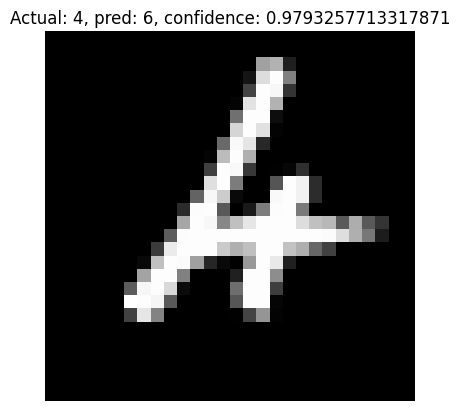

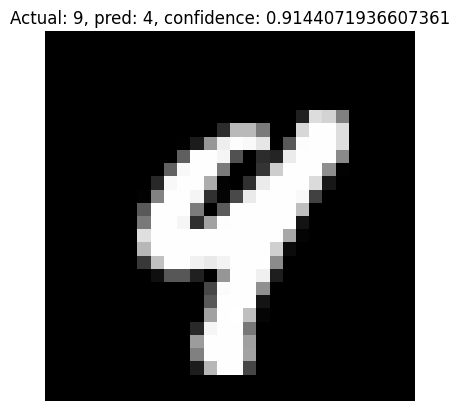

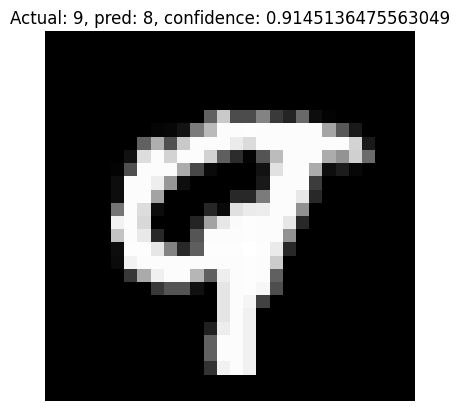

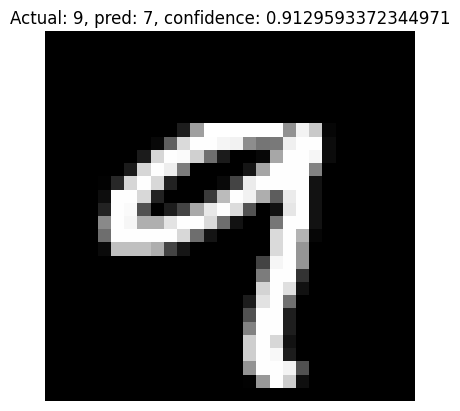

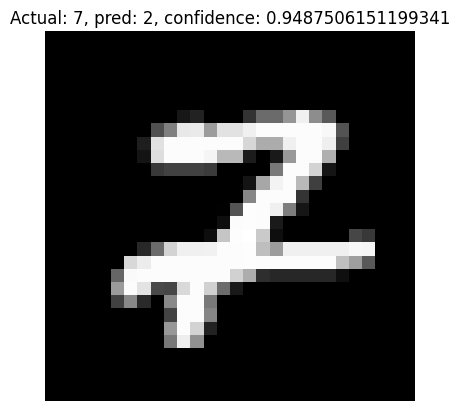

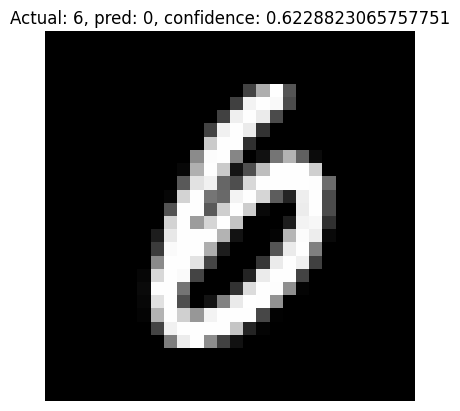

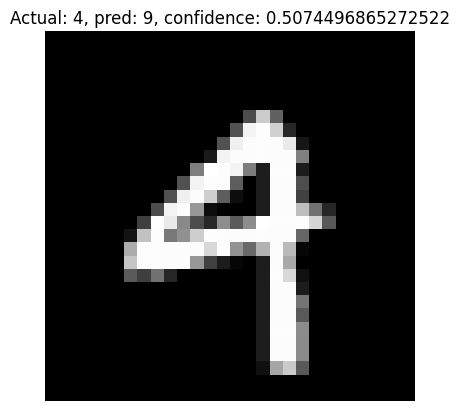

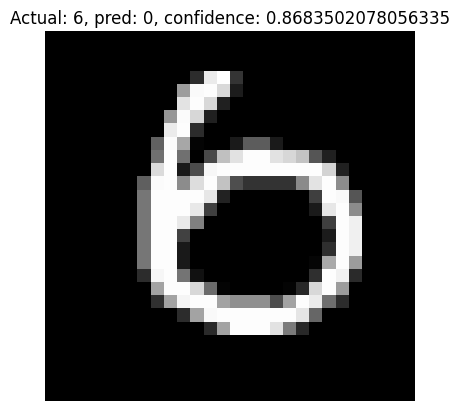

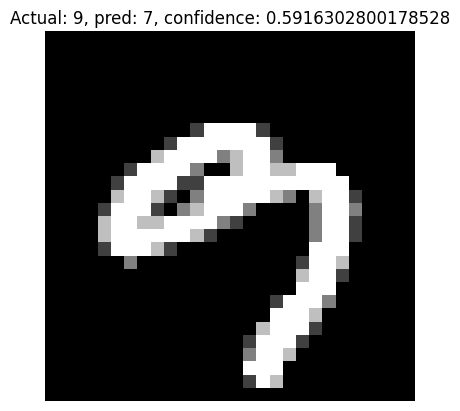

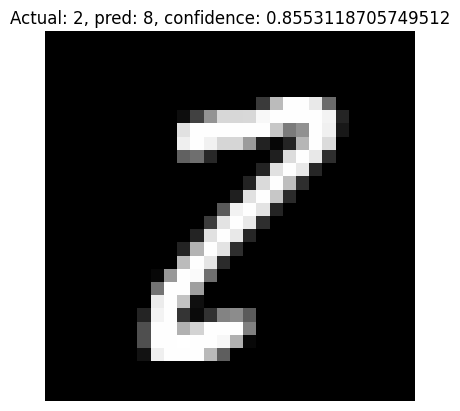

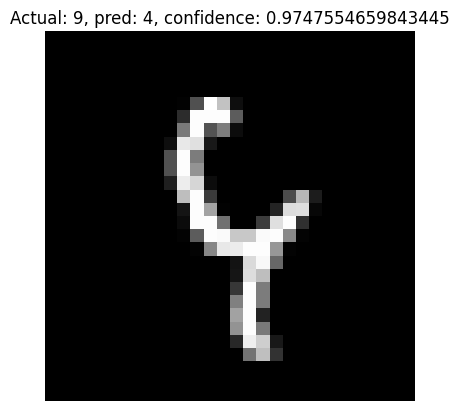

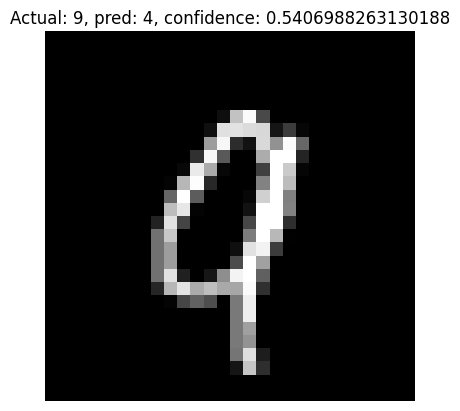

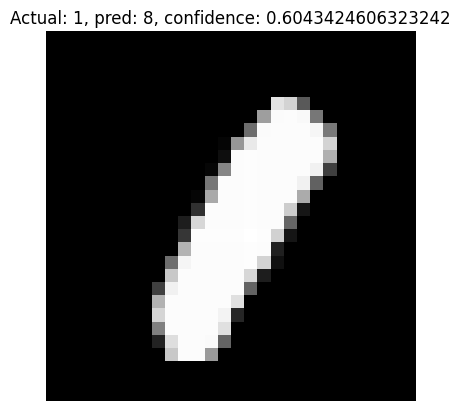

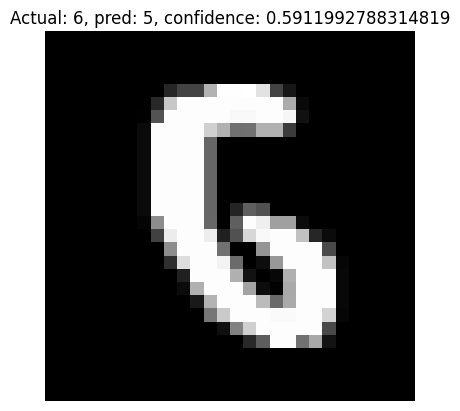

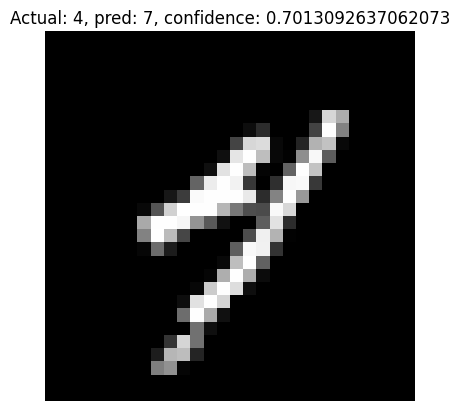

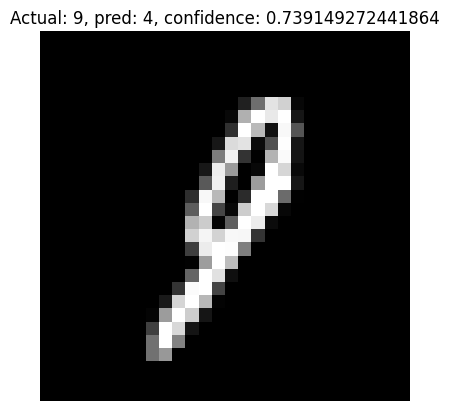

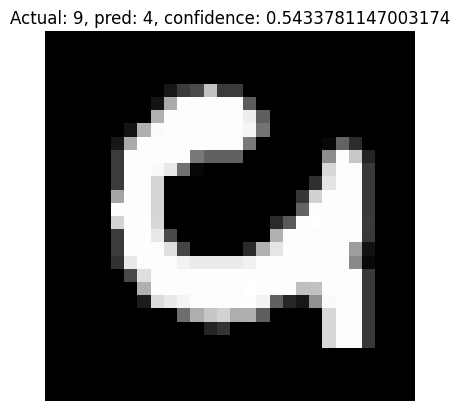

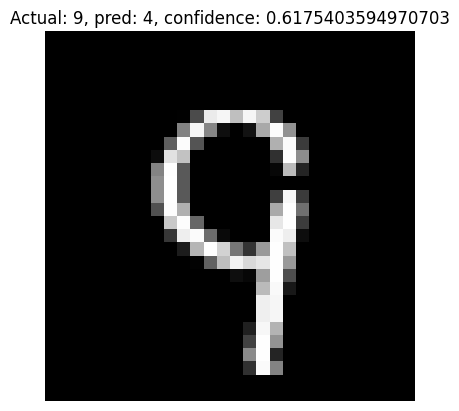

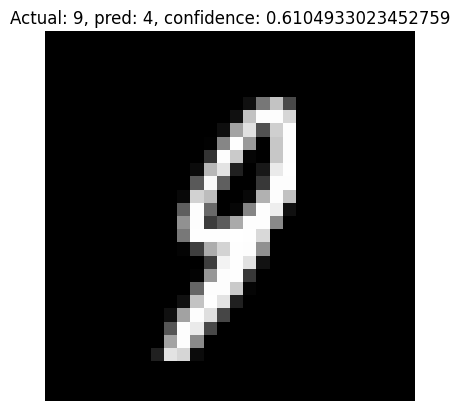

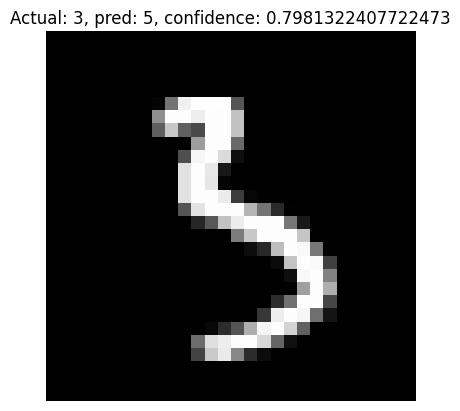

In [28]:
model.eval()
correct = 0
total = 0

mismatch = 0
wrong=[]
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        confidences, predictions = probabilities.max(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(dim=0)
        for conf, pred, label, img in zip(confidences, predictions, labels, images):
            if pred != label:
                wrong.append((conf, pred, label, img ))
        if len(wrong) >=20:
            break

import matplotlib.pyplot as plt
for conf, pred, label, img in wrong:
    plt.figure()
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Actual: {label}, pred: {pred}, confidence: {conf}")
    plt.axis("off")
    plt.show()
    

# print(f"Test Accuracy: {correct/total:0.4f}")